# **PHYSHING DECTATION**


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib 

from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,classification_report,accuracy_score,
    precision_score,recall_score,f1_score
    )

In [4]:
url=("https://raw.githubusercontent.com/mrrendex2006/machine-learning-from-scratch/refs/heads/main/dataset%20for%20practice/physhing%20url/Phishing_URL_Dataset.csv")
df=pd.read_csv(url)
# df=pd.read_csv('Phishing_URL_Dataset.csv')
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [5]:
df.shape

(235795, 56)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [7]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [8]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


In [9]:
print(df['label'].value_counts(normalize=True))

label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


In [10]:
print("Total row:",len(df))
print("number of repeatation of url in dataset:",df['URL'].duplicated().sum())
print("unique URL:",df['URL'].nunique())

Total row: 235795
number of repeatation of url in dataset: 425
unique URL: 235370


In [11]:
# checking if duplicated url have the same label.
duplicate_url=df[df['URL'].duplicated(keep=False)].sort_values('URL')
print(
    duplicate_url.groupby('URL')['label'].nunique().value_counts()
)

label
1    425
Name: count, dtype: int64


In [12]:
#Removing repeated urls
df=df.drop_duplicates(subset='URL').reset_index(drop=True)
print("Rows after removing duplicate URL: ",len(df))

Rows after removing duplicate URL:  235370


<class 'pandas.core.frame.DataFrame'>
(51, 1)


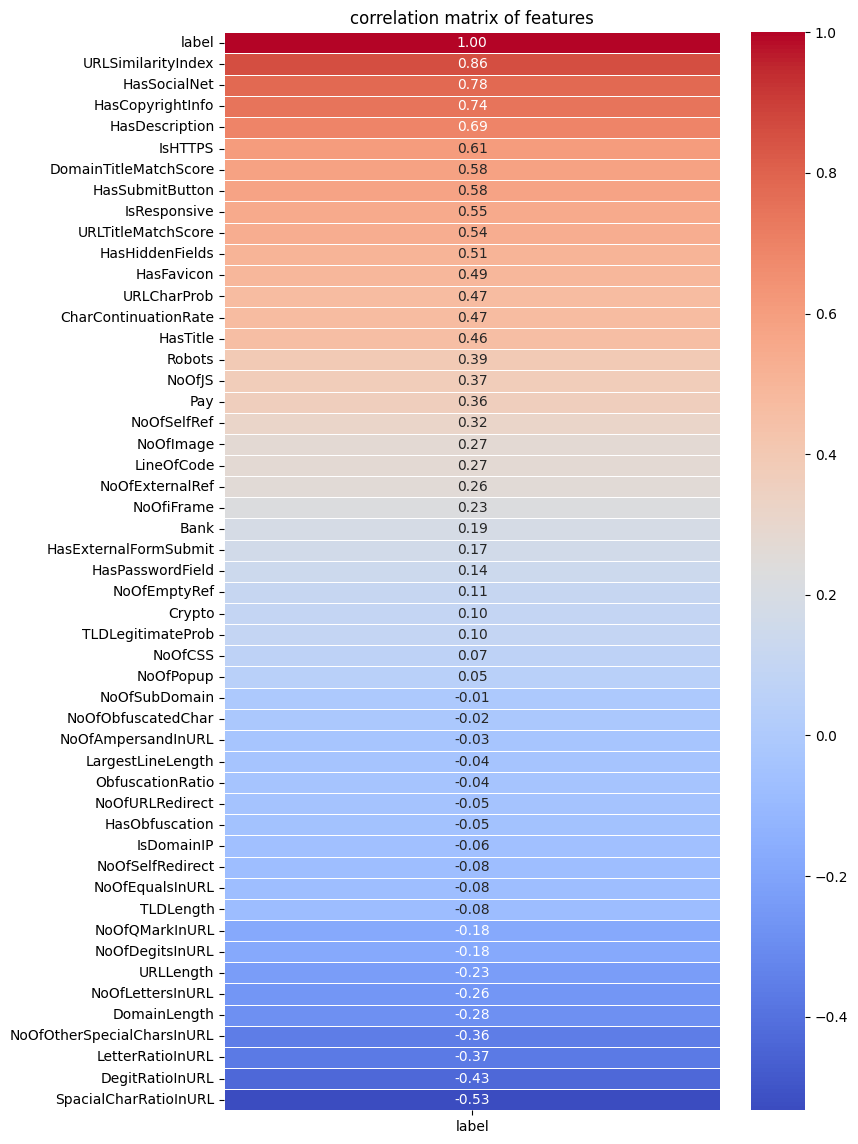

In [13]:
corr_with_label = df.corr(numeric_only=True)[['label']].sort_values(by='label',ascending=False)
print(type(corr_with_label))
print(corr_with_label.shape)

#ploting heatmap 

plt.figure(figsize=(8,14))
sns.heatmap(corr_with_label,annot=True, cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('correlation matrix of features')
plt.show()

In [14]:
top_n= 16
X_url=corr_with_label.drop('label').head(top_n).index.tolist()
# list of features we will use to train our model 
print("Selected features :\n",X_url)
target=df["label"]

Selected features :
 ['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton', 'IsResponsive', 'URLTitleMatchScore', 'HasHiddenFields', 'HasFavicon', 'URLCharProb', 'CharContinuationRate', 'HasTitle', 'Robots', 'NoOfJS']


In [15]:
X=df[X_url]
y=target
print("shape of the feature variable X:",X.shape)
print("shape of the feature variable y:",y.shape)

shape of the feature variable X: (235370, 16)
shape of the feature variable y: (235370,)


In [16]:
x_train,x_test,y_train,y_test=train_test_split(X,y, test_size=0.30,random_state=42,stratify=y)
print("shape of traing data :",x_train.shape)
print("shape of test data :",x_test.shape)

shape of traing data : (164759, 16)
shape of test data : (70611, 16)


In [17]:
x_train.columns

Index(['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo',
       'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton',
       'IsResponsive', 'URLTitleMatchScore', 'HasHiddenFields', 'HasFavicon',
       'URLCharProb', 'CharContinuationRate', 'HasTitle', 'Robots', 'NoOfJS'],
      dtype='object')

## **6.Feature scaling**

In [18]:
scaler=StandardScaler()
x_train_sc=scaler.fit_transform(x_train)
x_test_sc=scaler.transform(x_test)

In [19]:
lr=LogisticRegression(max_iter=1000)
cv_score_lr=cross_val_score(lr, x_train_sc, y_train, cv=5, scoring='accuracy')
print("LR-5 fold cv accuracy: %.4f +/- %.4f "%(cv_score_lr.mean(),cv_score_lr.std()))



LR-5 fold cv accuracy: 0.9998 +/- 0.0001 


In [20]:
lr.fit(x_train_sc,y_train)
y_pred_lr=lr.predict(x_test_sc)


In [21]:
cm_lr=confusion_matrix(y_test,y_pred_lr)
print("confusion_matrix(logistic regression):\n",cm_lr)

print("\nClassification report(logistic regression) :\n",classification_report(y_test,y_pred_lr))

confusion_matrix(logistic regression):
 [[30140    16]
 [    0 40455]]

Classification report(logistic regression) :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     30156
           1       1.00      1.00      1.00     40455

    accuracy                           1.00     70611
   macro avg       1.00      1.00      1.00     70611
weighted avg       1.00      1.00      1.00     70611



## **K-nearest neighbours**

In [ ]:
knn_param_grid={'n_neighbors':[3,5,7,9,11]}
knn_grid=GridSearchCV(KNeighborsClassifier(),knn_param_grid,cv=5,scoring='accuracy')
knn_grid.fit(x_train_sc,y_train)

In [ ]:
print('Best n_neighbors:',knn_grid.best_params_)
knn=knn_grid.best_estimator_
y_pred_knn=knn.predict(x_test_sc)

Best n_neighbors: {'n_neighbors': 3}


In [ ]:
cm_knn=confusion_matrix(y_test,y_pred_knn)
print("confusion_matrix(knn):\n",cm_knn)

print("Classification report(knn) :\n",classification_report(y_test,y_pred_knn))

confusion_matrix(knn):
 [[30087    69]
 [    9 40446]]
Classification report(knn) :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     30156
           1       1.00      1.00      1.00     40455

    accuracy                           1.00     70611
   macro avg       1.00      1.00      1.00     70611
weighted avg       1.00      1.00      1.00     70611



In [ ]:
rf_param_grid={
    'n_estimators':[200,300],
    'max_depth':[None,10,20],
    'min_samples_leaf':[1,2,4]
}
rf_grid=GridSearchCV(
    RandomForestClassifier(random_state=42),rf_param_grid,cv=5,scoring='accuracy',n_jobs=-1
)
rf_grid.fit(x_train,y_train)
rf_model=rf_grid.best_estimator_
y_pred_rf=rf_model.predict(x_test)

In [ ]:
cm_rf=confusion_matrix(y_test,y_pred_rf)
print("confusion_matrix(knn):\n",cm_rf)

print("Classification report(knn) :\n",classification_report(y_test,y_pred_rf))


confusion_matrix(knn):
 [[30152     4]
 [    0 40455]]
Classification report(knn) :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     30156
           1       1.00      1.00      1.00     40455

    accuracy                           1.00     70611
   macro avg       1.00      1.00      1.00     70611
weighted avg       1.00      1.00      1.00     70611



## **features importance** 

URLSimilarityIndex       0.352754
NoOfJS                   0.226851
HasSocialNet             0.144905
HasCopyrightInfo         0.090003
HasDescription           0.060615
IsHTTPS                  0.046006
HasSubmitButton          0.026461
DomainTitleMatchScore    0.022150
URLCharProb              0.007669
URLTitleMatchScore       0.005799
IsResponsive             0.005408
CharContinuationRate     0.004251
HasHiddenFields          0.003842
HasFavicon               0.002168
HasTitle                 0.000842
Robots                   0.000277
dtype: float64


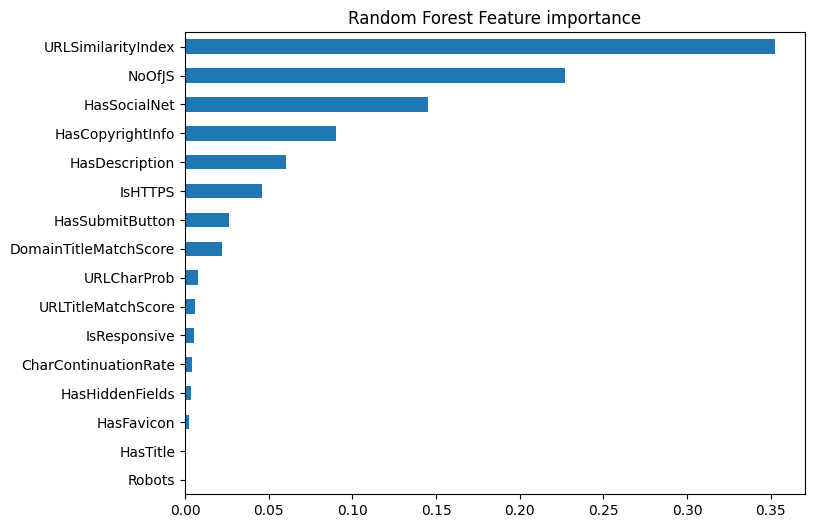

In [ ]:
importance = pd.Series(rf_model.feature_importances_,index=X_url).sort_values(ascending=False)
print(importance)
plt.figure(figsize=(8,6))
importance.plot(kind='barh')
plt.title('Random Forest Feature importance')
plt.gca().invert_yaxis()
plt.show()

## **Model Comperison**

In [ ]:
def summarize(name,y_true,y_pred):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision' : recall_score(y_true,y_pred),
        'f1': f1_score(y_true,y_pred)
    }

result = pd.DataFrame([
    summarize('Logistic Regression', y_test, y_pred_lr),
    summarize('KNN',y_test,y_pred_knn),
    summarize('Random Forest',y_test,y_pred_rf)
]).set_index('model')

print(result.round(4))

                     accuracy  precision      f1
model                                           
Logistic Regression    0.9998     1.0000  0.9998
KNN                    0.9989     0.9998  0.9990
Random Forest          0.9999     1.0000  1.0000


## **Save the best model**

In [ ]:
best_model_name=result['f1'].idxmax()
print('Best model bel f1 score:',best_model_name)

#Random forest doesn't need the scaler;if LR or KNN wins instead.
#save the fitted scaler alongside the model so inference stays consistent.
joblib.dump(rf_model,'phishing_rf_model.pkl')

Best model bel f1 score: Random Forest


['phishing_rf_model.pkl']